# 📊 E-Commerce Data Analytics Project

**Objective:** Analyze online retail transaction data to uncover revenue trends, top-performing products, customer purchasing behavior, and actionable business insights.

**Workflow:**
1. Import dataset (Kaggle E-Commerce Data)
2. Clean and preprocess the data
3. Perform exploratory data analysis (EDA)
4. Engineer features (RFM segmentation, time-based trends)
5. Export cleaned data for visualization in Power BI

**Dataset:** [Online Retail Dataset – Kaggle](https://www.kaggle.com/datasets/carrie1/ecommerce-data)  
**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Power BI

---
**Author:** *[Palak Rani]*  
**Date:** *[04/07/2026]*



**Loading and Exploring the Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data (encoding='latin1' is common for this dataset)
df = pd.read_csv('/content/data.csv', encoding='latin1')

# Basic exploration
print(df.shape)
print(df.info())
print(df.head())
print(df.describe())
print(df.isnull().sum())

(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029

**Data Cleaning**

In [2]:
# Drop rows with missing CustomerID (can't analyze customer behavior without it)
df = df.dropna(subset=['CustomerID'])

# Remove cancelled orders (InvoiceNo starting with 'C') and negative/zero quantities
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Remove duplicates
df = df.drop_duplicates()

# Convert data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)

# Create a Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (392692, 9)


Feature Engineering

In [3]:
# Date-based features
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Weekday'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

# RFM Analysis (Recency, Frequency, Monetary) — core customer segmentation technique
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,   # Recency
    'InvoiceNo': 'nunique',                                     # Frequency
    'Revenue': 'sum'                                            # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Score each metric 1-4 (quartiles) and combine into an RFM segment
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm.head())

   CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0       12346      326          1  77183.60       1       1       4       114
1       12347        2          7   4310.00       4       4       4       444
2       12348       75          4   1797.24       2       3       4       234
3       12349       19          1   1757.55       3       1       4       314
4       12350      310          1    334.40       1       1       2       112


**Exploratory Data Analysis (EDA) with Visuals**

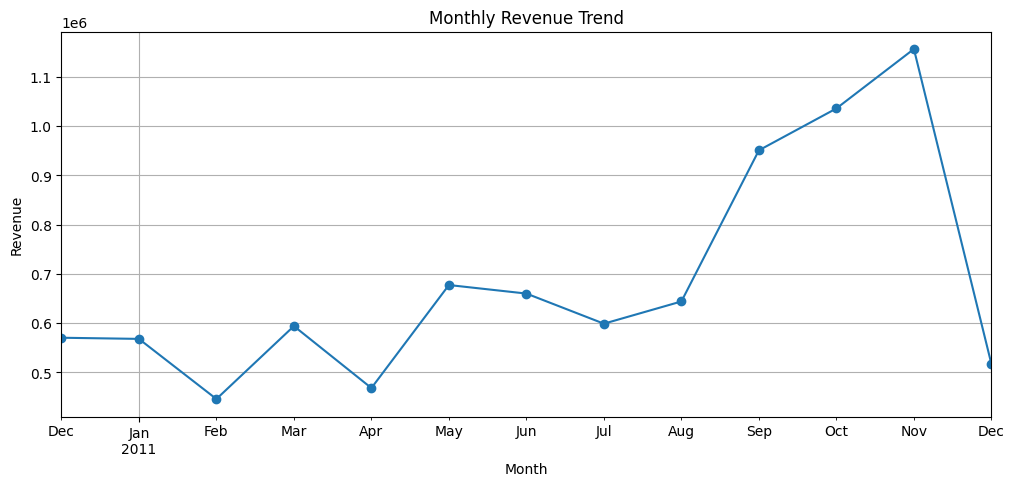

/tmp/ipykernel_605/3714312285.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')


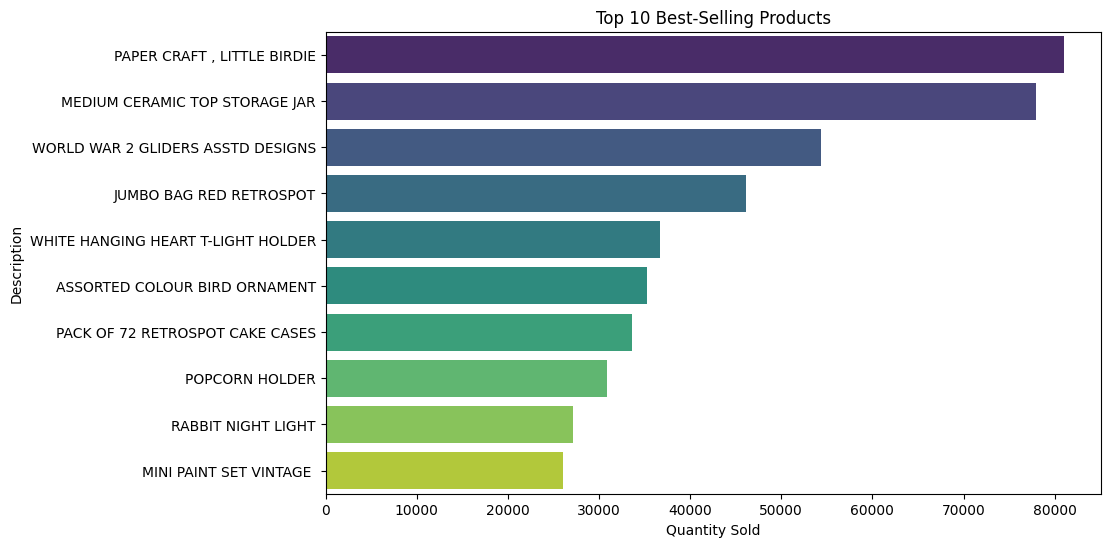

/tmp/ipykernel_605/3714312285.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_revenue.values, y=country_revenue.index, palette='mako')


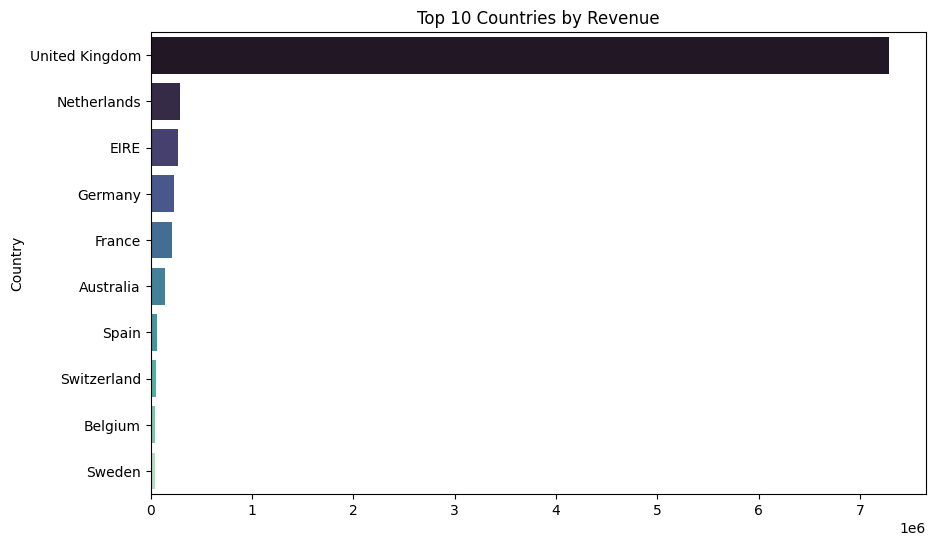

/tmp/ipykernel_605/3714312285.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekday_sales.index, y=weekday_sales.values, palette='coolwarm')


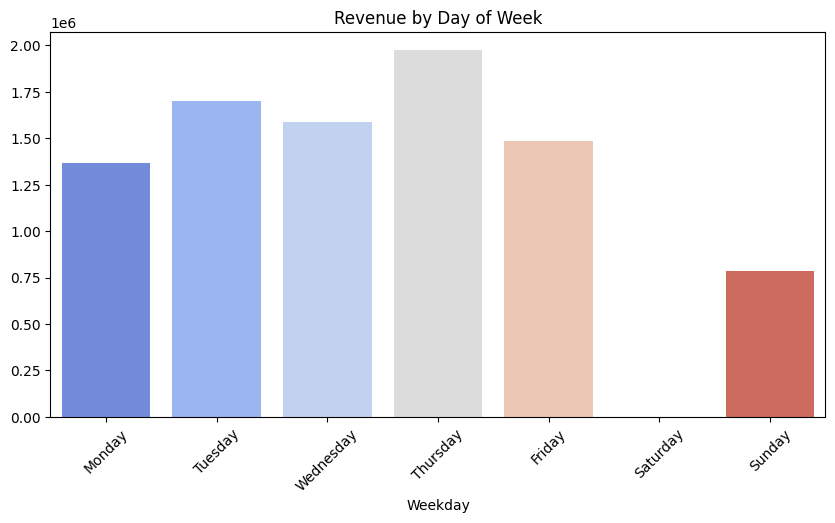

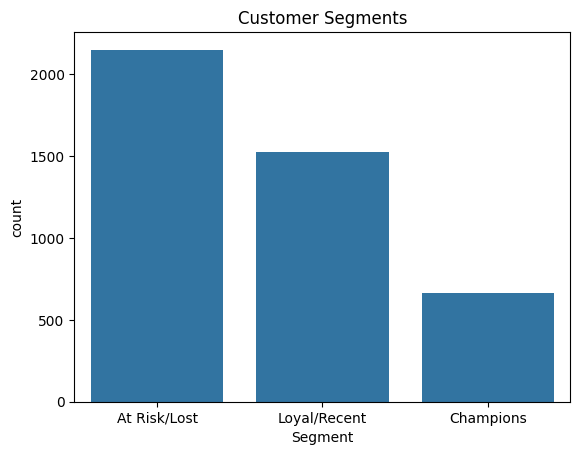

In [4]:
# 1. Monthly Revenue Trend
monthly_revenue = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Revenue'].sum()
plt.figure(figsize=(12,5))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.grid(True)
plt.show()

# 2. Top 10 Best-Selling Products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Quantity Sold')
plt.show()

# 3. Revenue by Country
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=country_revenue.values, y=country_revenue.index, palette='mako')
plt.title('Top 10 Countries by Revenue')
plt.show()

# 4. Sales by Day of Week
weekday_sales = df.groupby('Weekday')['Revenue'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.figure(figsize=(10,5))
sns.barplot(x=weekday_sales.index, y=weekday_sales.values, palette='coolwarm')
plt.title('Revenue by Day of Week')
plt.xticks(rotation=45)
plt.show()

# 5. Customer Segment Distribution (from RFM)
def segment_customer(row):
    if row['RFM_Score'] in ['444', '434', '443']:
        return 'Champions'
    elif int(row['R_Score']) in [4, 3]:
        return 'Loyal/Recent'
    elif int(row['R_Score']) in [1, 2]:
        return 'At Risk/Lost'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index)
plt.title('Customer Segments')
plt.show()

**Export Cleaned Data for Power BI**

In [5]:
df.to_csv('ecommerce_cleaned.csv', index=False)
rfm.to_csv('customer_rfm.csv', index=False)

from google.colab import files
files.download('ecommerce_cleaned.csv')
files.download('customer_rfm.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>